In [12]:
%matplotlib inline

import logging
import yaml
import json
import os
import joblib
from datetime import datetime
from pathlib import Path
from sklearn.base import clone

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# --- Абсолютные пути ---
ARTIFACTS_ROOT = Path('../artifacts').resolve()
CONFIGS_DIR = Path('../configs').resolve()
METRICS_DIR = ARTIFACTS_ROOT / 'metrics'
MODELS_DIR = ARTIFACTS_ROOT / 'models'
FIGURES_EXP = ARTIFACTS_ROOT / 'figures' / '01_exp'
CATBOOST_INFO_DIR = ARTIFACTS_ROOT / 'catboost_info'

for p in [METRICS_DIR, MODELS_DIR, FIGURES_EXP, CATBOOST_INFO_DIR, CONFIGS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

# --- Логгер ---
def setup_logger(log_path: str, name: str = "project"):
    logger = logging.getLogger(name)
    logger.handlers.clear()
    logger.setLevel(logging.INFO)
    logger.propagate = False
    fmt = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    sh = logging.StreamHandler()
    sh.setFormatter(fmt)
    logger.addHandler(sh)
    fh = logging.FileHandler(log_path, mode='w', encoding='utf-8')
    fh.setFormatter(fmt)
    logger.addHandler(fh)
    return logger

logger = setup_logger(str(ARTIFACTS_ROOT / "logs" / 'experiment.log'), 'experiment')
logger.info('Experiment logger initialized')

# --- Генерация конфигов ---
data_config = {
    'source_path': '../data/ENB2012_data.csv',
    'separator': ';',
    'decimal': ',',
    'dropna_how': 'all',
    'columns': {
        'numeric': ['X1', 'X2', 'X3', 'X4', 'X5', 'X7'],
        'categorical': ['X6', 'X8'],
        'targets': ['Y1', 'Y2']
    }
}
with open(CONFIGS_DIR / 'data.yaml', 'w', encoding='utf-8') as f:
    yaml.safe_dump(data_config, f, default_flow_style=False, allow_unicode=True)

experiment_config = {
    'random_state': 42,
    'test_size': 0.2,
    'preprocessing': {
        'numeric_scaler': 'StandardScaler',
        'categorical_encoder': 'OneHotEncoder',
        'handle_unknown': 'ignore'
    },
    'models': {
        'LinearRegression': {},
        'RandomForest': {'n_estimators': 150, 'n_jobs': -1},
        'CatBoost': {'iterations': 500, 'learning_rate': 0.05, 'verbose': 0},
        'Stacking': {
            'cv': 5, 'n_jobs': -1,
            'base_models': {
                'lr': {},
                'rf': {'n_estimators': 100, 'n_jobs': -1},
                'cb': {'iterations': 300, 'verbose': 0}
            },
            'final_estimator': 'LinearRegression'
        }
    }
}
with open(CONFIGS_DIR / 'experiment.yaml', 'w', encoding='utf-8') as f:
    yaml.safe_dump(experiment_config, f, default_flow_style=False, allow_unicode=True)

serving_config = {
    'artifacts_dir': '../artifacts',
    'risk_thresholds': {'low': 20.0, 'medium': 35.0},
    'server': {'host': '0.0.0.0', 'port': 8000}
}
with open(CONFIGS_DIR / 'serving.yaml', 'w', encoding='utf-8') as f:
    yaml.safe_dump(serving_config, f, default_flow_style=False, allow_unicode=True)

env_example = (
    "# Переменные окружения (не коммитить!)\n"
    "ARTIFACTS_PATH=./artifacts\n"
    "CONFIGS_PATH=./configs\n"
    "LOG_LEVEL=info\n"
)
with open(CONFIGS_DIR / '.env.example', 'w', encoding='utf-8') as f:
    f.write(env_example)

logger.info('Конфигурации сохранены в configs/')

# --- Загрузка конфигов ---
with open(CONFIGS_DIR / 'data.yaml', 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)
with open(CONFIGS_DIR / 'experiment.yaml', 'r', encoding='utf-8') as f:
    exp_cfg = yaml.safe_load(f)

# --- Вспомогательная функция для графиков ---
def save_and_show(fig, name, output_dir):
    plt.show()
    filepath = output_dir / f'{name}.png'
    fig.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.close(fig)
    logger.info(f'График сохранён: {filepath}')
    return filepath

2026-05-24 21:40:45,034 - INFO - Experiment logger initialized
2026-05-24 21:40:45,049 - INFO - Конфигурации сохранены в configs/


In [13]:
df = pd.read_csv(
    data_cfg['source_path'],
    sep=data_cfg['separator'],
    decimal=data_cfg['decimal']
)
df = df.dropna(how=data_cfg['dropna_how']).reset_index(drop=True)

num_cols = data_cfg['columns']['numeric']
cat_cols = data_cfg['columns']['categorical']
target_cols = data_cfg['columns']['targets']

df[cat_cols] = df[cat_cols].astype('category')

X = df.drop(columns=target_cols)
y = df[target_cols]

# Сплит: 70% train, 15% valid, 15% test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=exp_cfg['random_state']
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.176, random_state=exp_cfg['random_state']  # 0.176 ≈ 15%/85%
)

logger.info(f'Data split: train={len(X_train)}, valid={len(X_valid)}, test={len(X_test)}')

2026-05-24 21:40:45,109 - INFO - Data split: train=537, valid=115, test=116


In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown=exp_cfg['preprocessing']['handle_unknown'], sparse_output=False), cat_cols)
    ]
)

models_cfg = exp_cfg['models']

models = {
    'LinearRegression': Pipeline([
        ('prep', preprocessor),
        ('model', LinearRegression())
    ]),
    'RandomForest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(
            n_estimators=models_cfg['RandomForest']['n_estimators'],
            random_state=exp_cfg['random_state'],
            n_jobs=models_cfg['RandomForest']['n_jobs']
        ))
    ]),
    'CatBoost': Pipeline([
        ('prep', preprocessor),
        ('model', CatBoostRegressor(
            allow_writing_files=False,  # <-- отключает все записи на диск
            verbose=models_cfg['CatBoost']['verbose'],
            random_state=exp_cfg['random_state'],
            iterations=models_cfg['CatBoost']['iterations'],
            learning_rate=models_cfg['CatBoost']['learning_rate'],
            loss_function='RMSE'
        ))
    ]),
    'Stacking': Pipeline([
        ('prep', preprocessor),
        ('model', StackingRegressor(
            estimators=[
                ('lr', LinearRegression()),
                ('rf', RandomForestRegressor(
                    n_estimators=models_cfg['Stacking']['base_models']['rf']['n_estimators'],
                    random_state=exp_cfg['random_state'],
                    n_jobs=models_cfg['Stacking']['base_models']['rf']['n_jobs']
                )),
                ('cb', CatBoostRegressor(
                    allow_writing_files=False,  # <-- отключает все записи на диск
                    verbose=models_cfg['Stacking']['base_models']['cb']['verbose'],
                    random_state=exp_cfg['random_state'],
                    iterations=models_cfg['Stacking']['base_models']['cb']['iterations']
                ))
            ],
            final_estimator=LinearRegression(),
            cv=models_cfg['Stacking']['cv'],
            n_jobs=models_cfg['Stacking']['n_jobs']
        ))
    ])
}

logger.info('Model pipelines created')

2026-05-24 21:40:45,130 - INFO - Model pipelines created


In [15]:


results = []
fitted_pipelines = {}

for target in target_cols:
    logger.info(f'Training for target: {target}')
    y_tr = y_train[target]
    y_va = y_valid[target]
    y_te = y_test[target]
    
    for name, pipe_template in models.items():
        logger.info(f'  Training {name}...')
        
        if name == 'CatBoost':
            # Окончательное решение: отключаем запись файлов вообще
            pipe = Pipeline([
                ('prep', clone(preprocessor)),
                ('model', CatBoostRegressor(
                    allow_writing_files=False,  # <-- блокирует создание tmp/catboost_info
                    verbose=models_cfg['CatBoost']['verbose'],
                    random_state=exp_cfg['random_state'],
                    iterations=models_cfg['CatBoost']['iterations'],
                    learning_rate=models_cfg['CatBoost']['learning_rate'],
                    loss_function='RMSE'
                ))
            ])
        else:
            pipe = clone(pipe_template)
        
        # Обучение
        pipe.fit(X_train, y_tr)
        
        # Предсказания на всех наборах
        y_pred_train = pipe.predict(X_train)
        y_pred_valid = pipe.predict(X_valid)
        y_pred_test = pipe.predict(X_test)
        
        # Метрики train
        metrics_train = {
            'mae': mean_absolute_error(y_tr, y_pred_train),
            'rmse': np.sqrt(mean_squared_error(y_tr, y_pred_train)),
            'r2': r2_score(y_tr, y_pred_train)
        }
        # Метрики valid
        metrics_valid = {
            'mae': mean_absolute_error(y_va, y_pred_valid),
            'rmse': np.sqrt(mean_squared_error(y_va, y_pred_valid)),
            'r2': r2_score(y_va, y_pred_valid)
        }
        # Метрики test
        metrics_test = {
            'mae': mean_absolute_error(y_te, y_pred_test),
            'rmse': np.sqrt(mean_squared_error(y_te, y_pred_test)),
            'r2': r2_score(y_te, y_pred_test)
        }
        
        # Сбор результатов
        results.append({
            'Target': target, 'Model': name,
            'MAE_train': metrics_train['mae'], 'RMSE_train': metrics_train['rmse'], 'R2_train': metrics_train['r2'],
            'MAE_valid': metrics_valid['mae'], 'RMSE_valid': metrics_valid['rmse'], 'R2_valid': metrics_valid['r2'],
            'MAE_test': metrics_test['mae'], 'RMSE_test': metrics_test['rmse'], 'R2_test': metrics_test['r2']
        })
        
        fitted_pipelines[f'{name}_{target}'] = pipe
        logger.info(f'  {name} for {target}: R2_valid={metrics_valid["r2"]:.4f}, R2_test={metrics_test["r2"]:.4f}')

results_df = pd.DataFrame(results)
logger.info('Training completed')

2026-05-24 21:40:45,172 - INFO - Training for target: Y1
2026-05-24 21:40:45,175 - INFO -   Training LinearRegression...
2026-05-24 21:40:45,221 - INFO -   LinearRegression for Y1: R2_valid=0.9548, R2_test=0.9117
2026-05-24 21:40:45,223 - INFO -   Training RandomForest...
2026-05-24 21:40:45,654 - INFO -   RandomForest for Y1: R2_valid=0.9980, R2_test=0.9974
2026-05-24 21:40:45,655 - INFO -   Training CatBoost...
2026-05-24 21:40:45,991 - INFO -   CatBoost for Y1: R2_valid=0.9991, R2_test=0.9988
2026-05-24 21:40:45,993 - INFO -   Training Stacking...
2026-05-24 21:40:49,171 - INFO -   Stacking for Y1: R2_valid=0.9990, R2_test=0.9988
2026-05-24 21:40:49,172 - INFO - Training for target: Y2
2026-05-24 21:40:49,173 - INFO -   Training LinearRegression...
2026-05-24 21:40:49,234 - INFO -   LinearRegression for Y2: R2_valid=0.9146, R2_test=0.8923
2026-05-24 21:40:49,235 - INFO -   Training RandomForest...
2026-05-24 21:40:49,639 - INFO -   RandomForest for Y2: R2_valid=0.9813, R2_test=0.957

2026-05-24 21:40:51,775 - INFO - Saved: C:\ИИИ\AIE\project\artifacts\metrics\results_summary.csv


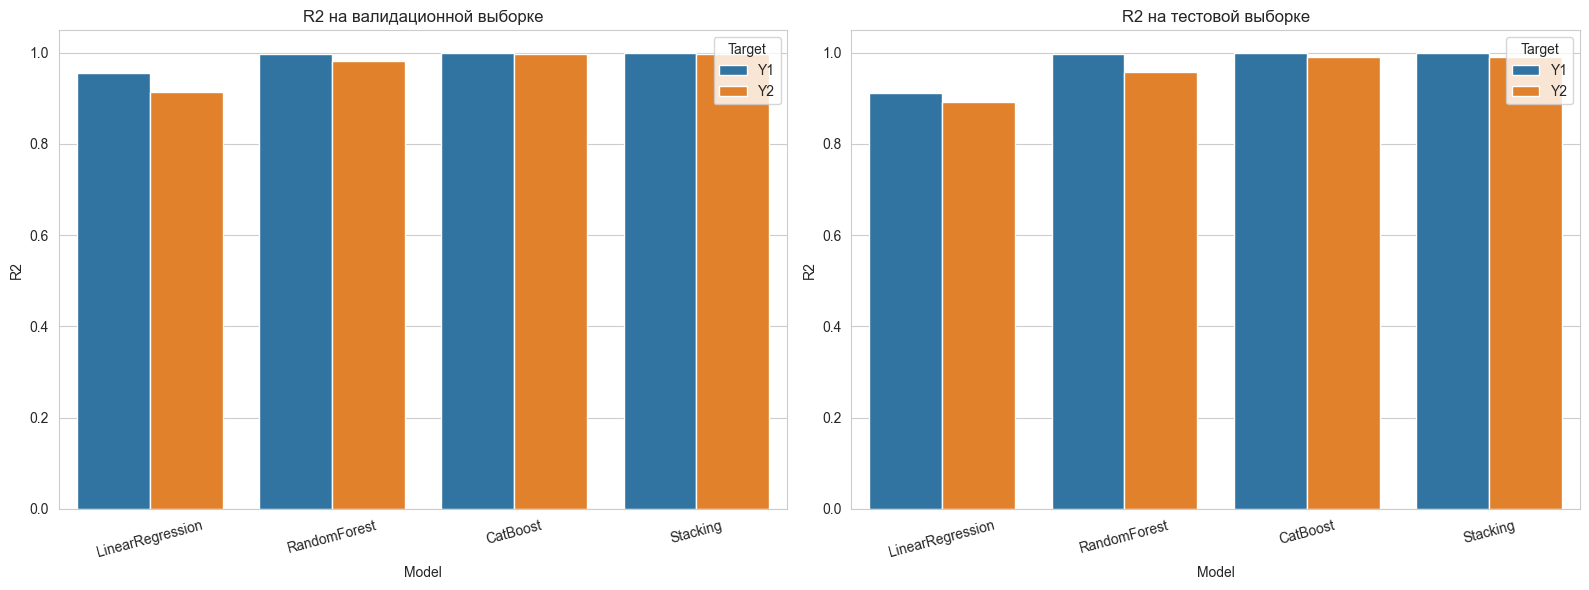

2026-05-24 21:40:52,637 - INFO - График сохранён: C:\ИИИ\AIE\project\artifacts\figures\01_exp\models_comparison_r2.png



Сводка по моделям (валидация):

Y1:
           Model  R2_valid  R2_test
LinearRegression    0.9548   0.9117
    RandomForest    0.9980   0.9974
        CatBoost    0.9991   0.9988
        Stacking    0.9990   0.9988

Y2:
           Model  R2_valid  R2_test
LinearRegression    0.9146   0.8923
    RandomForest    0.9813   0.9579
        CatBoost    0.9962   0.9907
        Stacking    0.9965   0.9909


In [16]:
results_df.to_csv(METRICS_DIR / 'results_summary.csv', index=False, float_format='%.4f')
logger.info(f'Saved: {METRICS_DIR / "results_summary.csv"}')

# График с валидацией
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(x='Model', y='R2_valid', hue='Target', data=results_df, ax=axes[0])
axes[0].set_title('R2 на валидационной выборке')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('R2')
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(x='Model', y='R2_test', hue='Target', data=results_df, ax=axes[1])
axes[1].set_title('R2 на тестовой выборке')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('R2')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
save_and_show(fig, 'models_comparison_r2', FIGURES_EXP)

# Печать сводки
print('\nСводка по моделям (валидация):')
for target in target_cols:
    print(f'\n{target}:')
    target_results = results_df[results_df['Target'] == target][['Model', 'R2_valid', 'R2_test']]
    print(target_results.to_string(index=False))

In [17]:
# Выбор по среднему R2 на валидации (а не на тесте!)
avg_r2_valid = results_df.groupby('Model')['R2_valid'].mean().sort_values(ascending=False)
final_model = avg_r2_valid.index[0]

selection_record = {
    'selected_model': final_model,
    'selection_criteria': 'max_mean_R2_valid',
    'validation_scores': {k: round(v, 4) for k, v in avg_r2_valid.items()},
    'test_scores': {k: round(results_df[results_df['Model']==k]['R2_test'].mean(), 4) for k in avg_r2_valid.index},
    'timestamp': datetime.now().isoformat(),
    'note': 'Model selected based on highest mean validation R2 to avoid test set leakage'
}
with open(METRICS_DIR / 'model_selection.json', 'w', encoding='utf-8') as f:
    json.dump(selection_record, f, indent=2, ensure_ascii=False)
logger.info(f'Saved: {METRICS_DIR / "model_selection.json"}')

# Сохранение только финальной модели
for target in target_cols:
    key = f'{final_model}_{target}'
    model_path = MODELS_DIR / f'{key}.pkl'
    joblib.dump(fitted_pipelines[key], model_path)
    logger.info(f'Saved model: {model_path}')

best_model_manifest = {
    'model_name': final_model,
    'targets': target_cols,
    'artifact_files': [f'{final_model}_{t}.pkl' for t in target_cols],
    'timestamp': datetime.now().isoformat(),
    'selection_criteria': selection_record['selection_criteria'],
    'preprocessor': 'ColumnTransformer(StandardScaler + OneHotEncoder)',
    'features': {'numeric': num_cols, 'categorical': cat_cols},
    'validation_performance': selection_record['validation_scores'],
    'test_performance': selection_record['test_scores']
}
with open(MODELS_DIR / 'best_model_manifest.json', 'w', encoding='utf-8') as f:
    json.dump(best_model_manifest, f, indent=2, ensure_ascii=False)
logger.info(f'Saved manifest: {MODELS_DIR / "best_model_manifest.json"}')

2026-05-24 21:40:52,674 - INFO - Saved: C:\ИИИ\AIE\project\artifacts\metrics\model_selection.json
2026-05-24 21:40:52,773 - INFO - Saved model: C:\ИИИ\AIE\project\artifacts\models\Stacking_Y1.pkl
2026-05-24 21:40:52,825 - INFO - Saved model: C:\ИИИ\AIE\project\artifacts\models\Stacking_Y2.pkl
2026-05-24 21:40:52,830 - INFO - Saved manifest: C:\ИИИ\AIE\project\artifacts\models\best_model_manifest.json


In [18]:
logger.info('Reproducibility check')
print('Проверка воспроизводимости:')
print(f'Размер данных: {df.shape}')
print(f'Пропуски: {df.isna().sum().sum()}')
print(f'Дубликаты: {df.duplicated().sum()}')
for target in target_cols:
    print(f'{target}: диапазон [{df[target].min():.2f}, {df[target].max():.2f}]')
print(f'Финальная модель: {final_model}')
print(f'Артефакты в metrics/: {[f.name for f in METRICS_DIR.iterdir()]}')
print(f'Артефакты в models/: {[f.name for f in MODELS_DIR.iterdir()]}')
print(f'Графики в figures/01_exp/: {[f.name for f in FIGURES_EXP.iterdir()]}')
print('Эксперимент завершён.')

2026-05-24 21:40:52,848 - INFO - Reproducibility check


Проверка воспроизводимости:
Размер данных: (768, 10)
Пропуски: 0
Дубликаты: 0
Y1: диапазон [6.01, 43.10]
Y2: диапазон [10.90, 48.03]
Финальная модель: Stacking
Артефакты в metrics/: ['model_selection.json', 'results_summary.csv']
Артефакты в models/: ['best_model_manifest.json', 'Stacking_Y1.pkl', 'Stacking_Y2.pkl']
Графики в figures/01_exp/: ['models_comparison_r2.png']
Эксперимент завершён.
